<a href="https://colab.research.google.com/github/sun-mengwei/dtb-colab-experiments/blob/codex%2Fgame-dynamics-dtb/DTB_Game_Ver2/cournot_5d_stochastic_dtb_vs_euler_maruyama.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 5D non-potential Cournot: clipped best response, neural-DTB versus Euler–Maruyama

This separate 5D notebook follows the independent-run 3D workflow without
changing older notebooks or shared modules. The smooth **MLP tangent basis**
maps $\mathbb R^5$ to $\mathbb R^5$.

Both methods use the requested **clipped best-response dynamics**:
$$
X_0\sim U([0,1]^5),\qquad S_i=\sum_{j\ne i}x_j,\qquad
B_i^+(x)=\max\{0,\mu S_i(1-S_i)\},
$$
$$
F_i^{\mathrm{clip}}(x)=2b\bigl(B_i^+(x)-x_i\bigr)
=2\bigl(\max\{0,2S_i(1-S_i)\}-x_i\bigr),\quad b=1,\ \mu=2,
$$
$$
dX_i=F_i^{\mathrm{clip}}(X)\,dt+0.1\,dW_i,\qquad t\in[0,1],
\qquad D=\Sigma\Sigma^\mathsf T=0.01I_5,\quad\Sigma=0.1I_5.
$$

The five Brownian components are independent. Both methods start from the
**same initial particles**, but have independent states, clocks, stopping
conditions, and histories. EM never uses the DTB score or tangent coefficients.

**What is clipped:** only the best response, before subtracting the current
state. Particle positions, scores, and Gaussian increments are not clipped.
This changes the original raw polynomial drift and agrees with the clipped
best-response field in the older 5D notebook. Additive noise can still make
coordinates negative: this is not a reflected SDE.

The five boundary equilibria, the origin and the symmetric reference appear
as plain red dots in snapshots at $t=0,0.2,0.5,1$. There are no point-name
annotations or callout lines. All seven are shown regardless of stability;
their names and full coordinates remain in the reference table in Block 2.
These are selected reference equilibria, not an exhaustive equilibrium search.

**Execution:** run Blocks 0–2, then Blocks 3 (DTB) and 4 (EM) in either order
or run either alone. Blocks 5–7 compare and save available results.
After changing the drift or parameters, rerun from Block 1 to avoid stale
histories. Block 2 resets both results; rerunning one simulation restarts only
that method. Rerun Blocks 5–7 afterwards to refresh plots.

## Block 0 — Shared repository setup

This notebook reuses `ResidualMLPMap`, `game_dtb_basis_matrices`, and
`map_at` from `run_game_dtb.py`; `count_trainable` from `network.py`;
and `flat_params` plus `jform_solve` from `dtb.py`. Spatial tangent
derivatives and score evolution come from the shared `utility.py`.

In [19]:
# BLOCK 0 — Locate the shared modules locally or clone the requested branch in Colab.
from pathlib import Path
import math
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, display

MODULE_FILES = ('run_game_dtb.py', 'network.py', 'dtb.py', 'utility.py')
EXPERIMENT_DIR = next(
    (
        folder
        for folder in (Path.cwd(), Path.cwd() / 'DTB_Game_Ver2')
        if all((folder / name).is_file() for name in MODULE_FILES)
    ),
    None,
)

if EXPERIMENT_DIR is None:
    if not Path('/content').is_dir():
        raise FileNotFoundError('Run from the repository root or DTB_Game_Ver2 directory.')
    repo = Path('/content/dtb-colab-experiments')
    if not (repo / '.git').exists():
        subprocess.run([
            'git', 'clone', '--depth', '1', '--branch', 'codex/game-dynamics-dtb',
            'https://github.com/sun-mengwei/dtb-colab-experiments.git', str(repo),
        ], check=True)
    else:
        subprocess.run(['git', '-C', str(repo), 'checkout', 'codex/game-dynamics-dtb'], check=True)
        subprocess.run(['git', '-C', str(repo), 'pull', '--ff-only'], check=True)
    EXPERIMENT_DIR = repo / 'DTB_Game_Ver2'

# Import the existing DTB, network, and map primitives requested for reuse.
sys.path.insert(0, str(EXPERIMENT_DIR.resolve()))
from run_game_dtb import ResidualMLPMap, game_dtb_basis_matrices
from network import count_trainable
from dtb import device, flat_params, jform_solve
from importlib import reload
import utility as stochastic_utility

stochastic_utility = reload(stochastic_utility)
from utility import (
    create_run_directory,
    diagnostics_markdown,
    euler_score_update,
    plot_tangent_diagnostics,
    sample_initial_with_score,
    save_run_data,
    tangent_velocity_spatial_terms,
)

print('Shared module directory:', EXPERIMENT_DIR)

Shared module directory: /content/dtb-colab-experiments/DTB_Game_Ver2


## Block 1 — Shared and method-specific controls

Adjust `DTB_H`, `DTB_T_FINAL`, `EM_H`, and `EM_T_FINAL` independently. Each
final time must lie on its method's grid. Snapshot times are matched afterwards
by physical time; they need not be available on both grids.

Optional `DTB_MAX_ABS_STATE` / `EM_MAX_ABS_STATE` limits stop a method when
any particle coordinate exceeds that magnitude. `None` disables this extra
limit; non-finite states always stop the affected method. No state is clipped.

The defaults retain N=2000, h=0.005 and T=1 from the 3D experiment.
Snapshots are shown only at t=0, 0.2, 0.5 and 1. DTB prints the start
and duration of every step by default; EM prints every ten steps. Timings for
**every attempted step** are retained for both methods. Change
`TIME_EVERY_DTB_STEP=False` for less output. A 5D tangent derivative is more
expensive than a 3D derivative; reduce N or width for a quick smoke test.

The fixed plot window only changes the view; every panel reports its visible
particle fraction, and all valid particle coordinates remain in the history.

In [20]:
# BLOCK 1 — Define the five-player game and every editable experiment control.
SAVE_RUN = False  # True creates a uniquely named folder under saved_runs/.
SEED = 2026
EM_SEED = SEED + 10_000

DIM = 5
N_PARTICLES = 2000
DTB_H = 0.005
DTB_T_FINAL = 1.0
EM_H = 0.005
EM_T_FINAL = 1.0
DTB_MAX_ABS_STATE = None  # Optional particle-magnitude stop, e.g. 1e6; never clips.
EM_MAX_ABS_STATE = None
SNAPSHOT_TIMES = (0.0, 0.2, 0.5, 1.0)

# The paper uses independent noise of amplitude 0.1 in every coordinate.
NOISE_STD = (0.1,) * DIM

# "uniform" matches the paper's samples and uses the exact interior score q_0=0.
# "gaussian" and "smoothed_uniform" provide globally smooth analytical scores.
INITIAL_LAW = 'uniform'
GAUSSIAN_MEAN = 0.5
GAUSSIAN_STD = 0.15
UNIFORM_SMOOTHING_STD = 0.02

NN_CHOICE = 'mlp'
NN_ACTIVATION = 'tanh'  # Smooth activation is required by grad(div(u)).
MLP_WIDTH = 32
MLP_DEPTH = 4
BASIS_SIZE = 128
SVD_RTOL = 1e-3
SVD_METHOD = 'svd_gpu'
JACOBIAN_CHUNK = 64
DERIVATIVE_CHUNK = 16
PRINT_EVERY = 10
TIME_EVERY_DTB_STEP = True

DTYPE = torch.float32
DEVICE = device()
COURNOT_B = 1.0
COURNOT_MU = 2.0
COORDINATE_PAIRS = ((1, 2), (3, 4), (4, 5))
COORDINATE_TRIPLES = ((1, 2, 3), (3, 4, 5))
PLOT_LIMITS = (-1.0, 1.0)  # Display only; no state is clipped.

# Separate 3D figures use the same view, limits, and displayed particle labels.
PLOT_3D_MAX_POINTS = None  # None shows every particle; otherwise a seeded subset.
PLOT_3D_ELEV = 22.0
PLOT_3D_AZIM = -55.0
PLOT_3D_POINT_SIZE = 2.0
PLOT_3D_ALPHA = 0.35

def game_velocity(x):
    """Five-player relaxation toward the nonnegative clipped best response."""
    if x.shape[-1] != DIM:
        raise ValueError(f'Expected states with last dimension {DIM}.')
    rivals = x.sum(dim=-1, keepdim=True) - x
    best_response = (COURNOT_MU * rivals * (1.0 - rivals)).clamp_min(0.0)
    return 2.0 * COURNOT_B * (best_response - x)


# The boundary coordinates below assume the paper's mu=2.
# If mu changes, update the references too; Block 2 checks every drift residual.
if not np.isfinite([COURNOT_B, COURNOT_MU]).all() or COURNOT_B <= 0 or COURNOT_MU <= 0:
    raise ValueError('Cournot b and mu must be finite and positive.')
symmetric_coordinate = (COURNOT_MU * (DIM - 1) - 1) / (COURNOT_MU * (DIM - 1)**2)
BOUNDARY_REFERENCES = torch.full((DIM, DIM), 5/18, device=DEVICE, dtype=DTYPE)
BOUNDARY_REFERENCES.fill_diagonal_(0.0)
KNOWN_EQUILIBRIA = torch.cat([
    torch.tensor([[0.0] * DIM, [symmetric_coordinate] * DIM], device=DEVICE, dtype=DTYPE),
    BOUNDARY_REFERENCES,
])
EQUILIBRIUM_LABELS = ['E_0', 'E_1'] + [f'R_{i+1}' for i in range(DIM)]

## Block 2 — Shared initial cloud and run bookkeeping

Both methods copy the same initial particles. This block samples the initial
score as well, but does not construct a neural network or run either method.
Each simulation initializes its own mutable state and random generator.

**Failure handling:** an invalid candidate step is rejected before it enters
the saved history. The result records the failed attempt/time and reason, and
retains every earlier valid state. Numerical overflow and DTB linear-algebra
failures stop only that simulation. Configuration/programming errors are still
raised rather than silently labeled as numerical instability.

For DTB, $q_0\in\mathbb R^{N\times5}$ is initialized to zero, the **interior**
score of the uniform density. The sharp uniform boundary does not have a
globally smooth score. This limitation is inherited from the 3D experiment;
the optional `smoothed_uniform` initial law changes the experiment and must
be applied to both methods through shared initialization.


### Audit of the seven plotted references

At $b=1,\mu=2$, all seven points satisfy $F^{\mathrm{clip}}(x)=0$.
In particular, $R_1=(0,5/18,5/18,5/18,5/18)$ has a negative **unclipped**
best response for player 1; clipping makes that player's drift zero.

Away from switching surfaces, the Jacobian has diagonal $-2b$ and
$$
\partial_j F_i^{\mathrm{clip}}
=2b\mu(1-2S_i)\,\mathbf 1_{\{\mu S_i(1-S_i)>0\}},\qquad j\ne i.
$$
The symmetric point has eigenvalues $(-14,1,1,1,1)$.
Each $R_i$ has $(-10,-2,2/3,2/3,2/3)$, so all five are unstable but still
plotted. These are eigenvalues of the **clipped** field, not the raw Jacobian
from the appendix.

At the origin, clipping is nonsmooth: no unique classical Jacobian exists.
Along the invariant positive diagonal $x=z\mathbf1$, small $z>0$ satisfies
$\dot z=14z-64z^2$, establishing instability. The audit does not treat an
autodiff convention at the kink as an actual Jacobian.

In [21]:
# BLOCK 2 — Shared initial data and run bookkeeping; no neural network is required for EM.
if DIM != 5:
    raise ValueError('This notebook audits and plots the five-player example; keep DIM=5.')
if not isinstance(PRINT_EVERY, int) or PRINT_EVERY < 1:
    raise ValueError('PRINT_EVERY must be a positive integer.')
if len(NOISE_STD) != DIM:
    raise ValueError('NOISE_STD needs one independent amplitude per player.')
if not SNAPSHOT_TIMES or any(not np.isfinite(t) or t < 0 for t in SNAPSHOT_TIMES):
    raise ValueError('Snapshot times must be nonempty, finite, and nonnegative.')
generator_device = DEVICE.type if DEVICE.type == 'cuda' else 'cpu'
initial_generator = torch.Generator(device=generator_device).manual_seed(SEED)
x_0, q_0, log_density_0 = sample_initial_with_score(
    N_PARTICLES, DIM, law=INITIAL_LAW, device=DEVICE, dtype=DTYPE,
    generator=initial_generator, gaussian_mean=GAUSSIAN_MEAN,
    gaussian_std=GAUSSIAN_STD, smoothing_std=UNIFORM_SMOOTHING_STD,
)
sigma = torch.tensor(NOISE_STD, device=DEVICE, dtype=DTYPE)
if not bool(torch.isfinite(sigma).all()) or bool((sigma < 0).any()):
    raise ValueError('Noise amplitudes must be finite and nonnegative.')
diffusion = torch.diag(sigma.square())
equilibrium_residual = float(game_velocity(KNOWN_EQUILIBRIA).norm(dim=1).max())
if equilibrium_residual > 2e-5:
    raise ValueError(f'A plotted reference has drift residual {equilibrium_residual:.3e}; '
                     'the boundary references assume mu=2. Update them if parameters change.')

# Reinitializing shared data clears old results; rerunning one method only replaces that method.
dtb_result = None
em_result = None
CONFIG = {
    'game_dimension': DIM, 'particles': N_PARTICLES,
    'drift_variant': 'clipped_best_response',
    'source_notebook_revision': '6d30ca2',
    'noise_std': list(NOISE_STD), 'diffusion_diagonal': sigma.square().cpu().tolist(),
    'initial_law': INITIAL_LAW, 'gaussian_mean': GAUSSIAN_MEAN,
    'gaussian_std': GAUSSIAN_STD, 'uniform_smoothing_std': UNIFORM_SMOOTHING_STD,
    'seed': SEED, 'device': str(DEVICE), 'dtype': str(DTYPE),
    'cournot_b': COURNOT_B, 'cournot_mu': COURNOT_MU,
    'maximum_equilibrium_residual': equilibrium_residual,
    'equilibria': KNOWN_EQUILIBRIA.cpu().tolist(),
    'equilibrium_labels': EQUILIBRIUM_LABELS,
    'output_root': str(EXPERIMENT_DIR / 'saved_runs'),
    'timing_scope': (
        'Synchronized numerical step attempts including finite-state checks and the first step; '
        'excludes initialization, diagnostics, CPU history copies, printing, plotting, and saving. '
        'Totals include the failed attempt, if any; common-horizon ratios use accepted steps only.'
    ),
}


def synchronize_device():
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize(DEVICE)
    elif DEVICE.type == 'mps':
        torch.mps.synchronize()


def step_count(h, final_time, max_abs_state):
    if not np.isfinite(h) or not np.isfinite(final_time) or h <= 0 or final_time <= 0:
        raise ValueError('The method step size and final time must be finite and positive.')
    count = round(final_time / h)
    if count < 1 or not np.isclose(count * h, final_time, rtol=0, atol=1e-10):
        raise ValueError('The method final time must be an integer multiple of its step size.')
    if max_abs_state is not None and (not np.isfinite(max_abs_state) or max_abs_state <= 0):
        raise ValueError('MAX_ABS_STATE must be None or a finite positive number.')
    return count


def require_finite(**values):
    bad = [name for name, value in values.items() if not bool(torch.isfinite(value).all())]
    if bad:
        raise FloatingPointError('Non-finite ' + ', '.join(bad))


def check_state_limit(particles, limit):
    if limit is not None and float(particles.abs().max()) > limit:
        raise FloatingPointError(f'Particle magnitude exceeded the configured limit {limit:g}')


def new_result(method, h, final_time, max_abs_state):
    count = step_count(h, final_time, max_abs_state)
    require_finite(initial_particles=x_0)
    return {
        'method': method, 'step_size': h, 'requested_final_time': final_time,
        'requested_steps': count, 'max_abs_state': max_abs_state,
        'particles': [x_0.detach().cpu().numpy().copy()], 'step_seconds': [],
        'status': 'completed', 'stop_reason': None, 'failed_step': None, 'failed_time': None,
        'metadata': {},
    }


def mark_stopped(result, step, error):
    result.update(status='stopped', failed_step=step + 1,
                  failed_time=(step + 1) * result['step_size'],
                  stop_reason=f'{type(error).__name__}: {error}')


def finish_result(result, wall_start):
    result['particles'] = np.stack(result['particles'])
    result['step_seconds'] = np.asarray(result['step_seconds'], dtype=float)
    result['completed_steps'] = len(result['particles']) - 1
    result['attempted_steps'] = len(result['step_seconds'])
    result['times'] = np.arange(len(result['particles']), dtype=float) * result['step_size']
    result['last_valid_time'] = float(result['times'][-1])
    result['compute_seconds'] = float(result['step_seconds'].sum())
    result['mean_attempt_seconds'] = (
        float(result['step_seconds'].mean()) if result['attempted_steps'] else None
    )
    synchronize_device()
    result['wall_seconds'] = time.perf_counter() - wall_start
    return result


def report_run(result):
    print(f'{result["method"]}: {result["status"]}; '
          f'{result["completed_steps"]}/{result["requested_steps"]} accepted steps; '
          f'last valid t={result["last_valid_time"]:.6g}; '
          f'compute={result["compute_seconds"]:.6f}s; loop wall={result["wall_seconds"]:.6f}s')
    if result['status'] == 'stopped':
        print(f'  Stopped on attempt {result["failed_step"]}, targeting t={result["failed_time"]:.6g}: '
              f'{result["stop_reason"]}. Earlier valid states remain available.')


print(f'Shared {DIM}D initial cloud: N={N_PARTICLES}, law={INITIAL_LAW}, seed={SEED}')
print(f'Device/dtype: {DEVICE}/{DTYPE}; sigma={NOISE_STD}')
print(f'DTB: h={DTB_H}, T={DTB_T_FINAL}; EM: h={EM_H}, T={EM_T_FINAL}')
print('Run either simulation cell next. Re-run this cell only to reset the shared initial data.')
if INITIAL_LAW == 'uniform':
    print('Uniform-score note: q_0=0 is the interior score; the boundary score is singular.')

Shared 5D initial cloud: N=2000, law=uniform, seed=2026
Device/dtype: cuda/torch.float32; sigma=(0.1, 0.1, 0.1, 0.1, 0.1)
DTB: h=0.005, T=1.0; EM: h=0.005, T=1.0
Run either simulation cell next. Re-run this cell only to reset the shared initial data.
Uniform-score note: q_0=0 is the interior score; the boundary score is singular.


In [22]:
# Evaluate all seven displayed equilibria in float64 on CPU.
reference_points = torch.cat([
    torch.zeros(1, DIM, dtype=torch.float64),
    torch.full((1, DIM), symmetric_coordinate, dtype=torch.float64),
    torch.full((DIM, DIM), 5/18, dtype=torch.float64).fill_diagonal_(0),
])
reference_labels = EQUILIBRIUM_LABELS
assert len(reference_points) == len(reference_labels) == 7
reference_audit = []
for label, point in zip(reference_labels, reference_points):
    rivals = point.sum() - point
    raw_best_response = COURNOT_MU * rivals * (1 - rivals)
    nonsmooth = bool((raw_best_response.abs() < 1e-12).any())
    residual = float(game_velocity(point).norm())
    stationary = residual < 1e-10
    eigenvalues = None
    classification = 'not an equilibrium'
    if stationary and not nonsmooth:
        # Inactive (clipped) response rows have zero off-diagonal derivatives.
        slopes = 2 * COURNOT_B * COURNOT_MU * (1 - 2 * rivals) * (raw_best_response > 0)
        jacobian = slopes[:, None].repeat(1, DIM)
        jacobian.fill_diagonal_(-2 * COURNOT_B)
        autodiff_jacobian = torch.func.jacrev(game_velocity)(point)
        torch.testing.assert_close(jacobian, autodiff_jacobian, atol=1e-12, rtol=1e-12)
        eigenvalues = torch.linalg.eigvals(jacobian)
        largest_real = float(eigenvalues.real.max())
        classification = ('unstable' if largest_real > 1e-10 else
                          'asymptotically stable' if largest_real < -1e-10 else
                          'linearization inconclusive')
    elif stationary:
        # Do not quote a spurious classical Jacobian at a switching point.
        diagonal_growth = 2 * COURNOT_B * (COURNOT_MU * (DIM - 1) - 1)
        classification = ('unstable (positive-diagonal perturbation)'
                          if bool((point == 0).all()) and diagonal_growth > 0
                          else 'nonsmooth; stability not classified')
    reference_audit.append({
        'label': label, 'point': point.tolist(), 'drift': game_velocity(point).tolist(),
        'drift_norm': residual, 'stationary': stationary, 'classification': classification,
        'nonsmooth': nonsmooth,
        'jacobian_eigenvalues_real': None if eigenvalues is None else eigenvalues.real.tolist(),
        'jacobian_eigenvalues_imag': None if eigenvalues is None else eigenvalues.imag.tolist(),
    })
if not all(row['stationary'] for row in reference_audit):
    raise ValueError('Every displayed reference must be a zero of the current clipped drift.')
if COURNOT_B == 1 and COURNOT_MU == 2:
    assert reference_audit[0]['nonsmooth']
    assert reference_audit[0]['jacobian_eigenvalues_real'] is None
    torch.testing.assert_close(torch.sort(torch.tensor(reference_audit[1]['jacobian_eigenvalues_real'])).values,
                               torch.tensor([-14., 1., 1., 1., 1.]))
    for row in reference_audit[2:]:
        torch.testing.assert_close(torch.sort(torch.tensor(row['jacobian_eigenvalues_real'])).values,
                                   torch.tensor([-10., -2., 2/3, 2/3, 2/3]))
reference_table = '\n'.join([
    '| Label | Coordinates | Clipped-drift norm | Deterministic stability |',
    '| :--- | :--- | ---: | :--- |',
    *[f'| {row["label"]} | {tuple(round(v, 6) for v in row["point"])} | '
      f'{row["drift_norm"]:.6g} | {row["classification"]} |' for row in reference_audit],
])
CONFIG['reference_audit'] = reference_audit
display(Markdown(reference_table))
print('All seven reference equilibria are shown as red dots, regardless of stability.')

| Label | Coordinates | Clipped-drift norm | Deterministic stability |
| :--- | :--- | ---: | :--- |
| E_0 | (0.0, 0.0, 0.0, 0.0, 0.0) | 0 | unstable (positive-diagonal perturbation) |
| E_1 | (0.21875, 0.21875, 0.21875, 0.21875, 0.21875) | 0 | unstable |
| R_1 | (0.0, 0.277778, 0.277778, 0.277778, 0.277778) | 2.22045e-16 | unstable |
| R_2 | (0.277778, 0.0, 0.277778, 0.277778, 0.277778) | 2.22045e-16 | unstable |
| R_3 | (0.277778, 0.277778, 0.0, 0.277778, 0.277778) | 2.22045e-16 | unstable |
| R_4 | (0.277778, 0.277778, 0.277778, 0.0, 0.277778) | 2.22045e-16 | unstable |
| R_5 | (0.277778, 0.277778, 0.277778, 0.277778, 0.0) | 2.22045e-16 | unstable |

All seven reference equilibria are shown as red dots, regardless of stability.


## Block 3 — Stochastic DTB tangent and score update

At step $k$, the Fokker--Planck transport target is

$$
g_{k,i}=F^{\mathrm{clip}}(x_{k,i})-\frac12Dq_{k,i}.
$$

The selected neural tangent basis is projected onto this target:

$$
\alpha_k=\arg\min_\alpha\sum_i\|J_{k,i}^S\alpha-g_{k,i}\|_2^2,
\qquad u_k(x)=\partial_{\theta_S}f_{\theta_0}(x)\alpha_k.
$$

Particles and attached scores use the same old-step velocity:

$$
x_i^{k+1}=x_i^k+h u_k(x_i^k),
$$

$$
q_i^{k+1}=q_i^k-h\left([D_xu_k(x_i^k)]^\mathsf{T}q_i^k
+\nabla_x[\nabla_x\!\cdot u_k](x_i^k)\right).
$$

This is the ordinary fixed-basis DTB update: there is no resampling, refit,
score network, or post-run polish step.

This cell runs DTB alone and stores `dtb_result`. Its history and diagnostics
may be shorter than the requested horizon if it stops early. Network setup is
local to this cell, so EM can run even when DTB has not been initialized.

**Timing:** each method times synchronized numerical step attempts, including
finite-state checks. Initialization, diagnostics, history copies, printing,
plotting, and saving are excluded. The first step is included (no warm-up).
Each result also records its own loop wall time. A failed attempt is included
in its total compute time, but excluded from common-horizon comparisons.

Here particles, targets, and scores have shape `(N,5)`; the spatial Jacobian
has shape `(N,5,5)`. The selected stacked basis has shape `(5*N,BASIS_SIZE)`.
The row-vector expression `q_k @ diffusion.T` represents the column-vector
product D q for each particle. D is the covariance, not the noise amplitude.

In [14]:
# BLOCK 3 — Independent DTB run. This cell never reads or changes em_result.
def run_dtb():
    if NN_ACTIVATION not in {'tanh', 'gelu', 'silu'}:
        raise ValueError('Score evolution requires a twice-differentiable activation.')
    result = new_result('Neural-DTB', DTB_H, DTB_T_FINAL, DTB_MAX_ABS_STATE)
    h = result['step_size']
    # Rebuild the same seeded network and sub-basis on every DTB run.
    torch.manual_seed(SEED)
    if DEVICE.type == 'cuda':
        torch.cuda.manual_seed_all(SEED)
    mlp = ResidualMLPMap(
        dim=DIM, width=MLP_WIDTH, depth=MLP_DEPTH, activation=NN_ACTIVATION,
        dtype=DTYPE, zero_init_output=False,
    ).net.to(DEVICE)
    parameter_count = count_trainable(mlp)
    theta_0, structure, _ = flat_params(mlp)
    mlp.requires_grad_(False)
    if not isinstance(BASIS_SIZE, int) or not 1 <= BASIS_SIZE <= parameter_count:
        raise ValueError(f'BASIS_SIZE must be in [1, {parameter_count}].')
    basis_generator = torch.Generator(device='cpu').manual_seed(SEED)
    selected = torch.randperm(parameter_count, generator=basis_generator)[:BASIS_SIZE]
    selected = selected.sort().values.to(DEVICE)
    result['metadata'] = {
        'network': NN_CHOICE, 'activation': NN_ACTIVATION, 'width': MLP_WIDTH,
        'depth': MLP_DEPTH, 'trainable_parameters': parameter_count, 'basis_size': BASIS_SIZE,
        'selected_parameter_indices': selected.cpu().tolist(), 'svd_rtol': SVD_RTOL,
        'svd_method': SVD_METHOD, 'jacobian_chunk': JACOBIAN_CHUNK,
        'derivative_chunk': DERIVATIVE_CHUNK, 'seed': SEED,
    }
    x_k, q_k, log_density_k = x_0.clone(), q_0.clone(), log_density_0.clone()
    scores = [q_k.detach().cpu().numpy().copy()]
    log_densities = [log_density_k.detach().cpu().numpy().copy()]
    coefficients, records = [], []
    synchronize_device()
    wall_start = time.perf_counter()
    for step in range(result['requested_steps']):
        if TIME_EVERY_DTB_STEP or (step + 1) % PRINT_EVERY == 0 or step == 0:
            print(f'DTB starting step {step + 1}/{result["requested_steps"]} ...', flush=True)
        synchronize_device()
        start = time.perf_counter()
        try:
            drift_k = game_velocity(x_k)
            diffusion_correction = 0.5 * (q_k @ diffusion.T)
            target_k = drift_k - diffusion_correction
            require_finite(target=target_k)
            _, jacobian_tensor, stacked_jacobian = game_dtb_basis_matrices(
                theta_0, selected, x_k, mlp, structure, chunk=JACOBIAN_CHUNK,
            )
            require_finite(tangent_basis=stacked_jacobian)
            alpha_k = jform_solve(
                stacked_jacobian, target_k.reshape(-1), rtol=SVD_RTOL, method=SVD_METHOD,
            )
            require_finite(coefficients=alpha_k)
            tangent_k, grad_u_k, divergence_k, grad_divergence_k = tangent_velocity_spatial_terms(
                theta_0, selected, alpha_k, x_k, mlp, structure, chunk_size=DERIVATIVE_CHUNK,
            )
            q_next, transported_score, score_source = euler_score_update(
                q_k, grad_u_k, grad_divergence_k, h,
            )
            x_next = x_k + h * tangent_k
            log_density_next = log_density_k - h * divergence_k
            require_finite(particles=x_next, score=q_next, log_density=log_density_next)
            check_state_limit(x_next, DTB_MAX_ABS_STATE)
        except (FloatingPointError, torch.linalg.LinAlgError) as error:
            mark_stopped(result, step, error)
        finally:
            synchronize_device()
            result['step_seconds'].append(time.perf_counter() - start)
        if result['status'] == 'stopped':
            break

        # Diagnostics and CPU copies are outside the numerical-step timer.
        # Double-precision norms avoid overflow of diagnostics for large finite states.
        norm = lambda value: float(value.double().norm())
        particle_scale = math.sqrt(N_PARTICLES)
        records.append({
            'time': step * h,
            'relative_projection_error': norm(tangent_k - target_k) / max(norm(target_k), 1e-30),
            'alpha_norm': norm(alpha_k), 'score_rms': norm(q_k) / particle_scale,
            'diffusion_rms': norm(diffusion_correction) / particle_scale,
            'target_rms': norm(target_k) / particle_scale,
            'tangent_rms': norm(tangent_k) / particle_scale,
            'score_transport_rms': norm(transported_score) / particle_scale,
            'score_source_rms': norm(score_source) / particle_scale,
        })
        coefficients.append(alpha_k.detach().cpu().numpy().copy())
        x_k, q_k, log_density_k = x_next.detach(), q_next.detach(), log_density_next.detach()
        result['particles'].append(x_k.cpu().numpy().copy())
        scores.append(q_k.cpu().numpy().copy())
        log_densities.append(log_density_k.cpu().numpy().copy())
        if TIME_EVERY_DTB_STEP or (step + 1) % PRINT_EVERY == 0 or step in (0, result['requested_steps'] - 1):
            print(f'DTB k={step + 1}/{result["requested_steps"]}, t={(step + 1) * h:.4f}, '
                  f'rel.err={records[-1]["relative_projection_error"]:.3e}, '
                  f'||alpha||={records[-1]["alpha_norm"]:.3e}, '
                  f'score.rms={records[-1]["score_rms"]:.3e}, '
                  f'step={result["step_seconds"][-1]:.6f}s', flush=True)
    result['scores'] = np.stack(scores)
    result['log_density'] = np.stack(log_densities)
    result['coefficients'] = np.stack(coefficients) if coefficients else np.empty((0, BASIS_SIZE))
    result['diagnostics'] = records
    result['solve_times'] = np.asarray([record['time'] for record in records])
    return finish_result(result, wall_start)


dtb_result = run_dtb()
report_run(dtb_result)

DTB starting step 1/200 ...
DTB k=1/200, t=0.0050, rel.err=9.029e-02, ||alpha||=2.492e+02, score.rms=0.000e+00, step=7.323235s
DTB starting step 2/200 ...
DTB k=2/200, t=0.0100, rel.err=9.246e-02, ||alpha||=2.410e+02, score.rms=7.217e-03, step=2.957630s
DTB starting step 3/200 ...
DTB k=3/200, t=0.0150, rel.err=9.445e-02, ||alpha||=2.390e+02, score.rms=1.435e-02, step=2.942037s
DTB starting step 4/200 ...
DTB k=4/200, t=0.0200, rel.err=9.617e-02, ||alpha||=2.454e+02, score.rms=2.160e-02, step=2.949095s
DTB starting step 5/200 ...
DTB k=5/200, t=0.0250, rel.err=9.834e-02, ||alpha||=2.412e+02, score.rms=2.902e-02, step=3.979170s
DTB starting step 6/200 ...
DTB k=6/200, t=0.0300, rel.err=1.001e-01, ||alpha||=2.480e+02, score.rms=3.688e-02, step=2.996744s
DTB starting step 7/200 ...
DTB k=7/200, t=0.0350, rel.err=1.020e-01, ||alpha||=2.541e+02, score.rms=4.491e-02, step=2.990011s
DTB starting step 8/200 ...
DTB k=8/200, t=0.0400, rel.err=1.038e-01, ||alpha||=2.617e+02, score.rms=5.298e-02,

## Block 4 — Independent Euler–Maruyama simulation

Run this cell after Block 2; Block 3 is optional. EM uses its own step size,
horizon, initial-state copy, and freshly seeded Gaussian-noise generator:

$$
x_{k+1}^{\mathrm{EM}}=x_k^{\mathrm{EM}}+h_{\mathrm{EM}}F^{\mathrm{clip}}(x_k^{\mathrm{EM}})
+\sqrt{h_{\mathrm{EM}}}\,\operatorname{diag}(\sigma)\xi_k,
\qquad \xi_k\sim N(0,I_5).
$$

The result is `em_result`; rerunning this cell does not rerun or modify DTB.
A non-finite EM step stops EM while retaining its valid snapshots.

In [15]:
# BLOCK 4 — Independent EM run. Run after shared initialization, with or without DTB.
@torch.no_grad()
def run_em():
    result = new_result('Euler--Maruyama', EM_H, EM_T_FINAL, EM_MAX_ABS_STATE)
    h = result['step_size']
    em_k = x_0.clone()
    # A fresh private generator makes reruns reproducible, regardless of DTB execution order.
    generator = torch.Generator(device=generator_device).manual_seed(EM_SEED)
    result['metadata'] = {'seed': EM_SEED}
    synchronize_device()
    wall_start = time.perf_counter()
    for step in range(result['requested_steps']):
        synchronize_device()
        start = time.perf_counter()
        try:
            noise = torch.randn(em_k.shape, device=DEVICE, dtype=DTYPE, generator=generator)
            em_next = em_k + h * game_velocity(em_k) + math.sqrt(h) * sigma * noise
            require_finite(particles=em_next)
            check_state_limit(em_next, EM_MAX_ABS_STATE)
        except FloatingPointError as error:
            mark_stopped(result, step, error)
        finally:
            synchronize_device()
            result['step_seconds'].append(time.perf_counter() - start)
        if result['status'] == 'stopped':
            break
        em_k = em_next.detach()
        result['particles'].append(em_k.cpu().numpy().copy())
        if (step + 1) % PRINT_EVERY == 0 or step in (0, result['requested_steps'] - 1):
            print(f'EM  k={step + 1}/{result["requested_steps"]}, t={(step + 1) * h:.4f}, '
                  f'step={result["step_seconds"][-1]:.6f}s', flush=True)
    return finish_result(result, wall_start)


em_result = run_em()
report_run(em_result)

EM  k=1/200, t=0.0050, step=0.001251s
EM  k=10/200, t=0.0500, step=0.000310s
EM  k=20/200, t=0.1000, step=0.000317s
EM  k=30/200, t=0.1500, step=0.000304s
EM  k=40/200, t=0.2000, step=0.000309s
EM  k=50/200, t=0.2500, step=0.000317s
EM  k=60/200, t=0.3000, step=0.000322s
EM  k=70/200, t=0.3500, step=0.000373s
EM  k=80/200, t=0.4000, step=0.000366s
EM  k=90/200, t=0.4500, step=0.000369s
EM  k=100/200, t=0.5000, step=0.000327s
EM  k=110/200, t=0.5500, step=0.000310s
EM  k=120/200, t=0.6000, step=0.000411s
EM  k=130/200, t=0.6500, step=0.000320s
EM  k=140/200, t=0.7000, step=0.000295s
EM  k=150/200, t=0.7500, step=0.000297s
EM  k=160/200, t=0.8000, step=0.000299s
EM  k=170/200, t=0.8500, step=0.000294s
EM  k=180/200, t=0.9000, step=0.000595s
EM  k=190/200, t=0.9500, step=0.000311s
EM  k=200/200, t=1.0000, step=0.000322s
Euler--Maruyama: completed; 200/200 accepted steps; last valid t=1; compute=0.092619s; loop wall=0.129635s


## Block 5 — Status and timing comparison

Only exact matching physical times are compared. No interpolation, repeated
last state, or valid-particle filtering fills a missing snapshot. A failure
of even one particle stops that method's whole ensemble; the first invalid
attempt is recorded but excluded from the valid history. An optional
magnitude threshold is a stop condition, never clipping.

The compute-time ratio uses only accepted steps up to the latest common
time. It is not an equal-accuracy benchmark. Timers synchronize accelerator
work; the first attempt is included, and compilation/warm-up is not removed.

In [16]:
# BLOCK 5 — Compare completed/partial results only after the independent simulations.
runs = {'dtb': dtb_result, 'em': em_result}
if all(result is None for result in runs.values()):
    raise ValueError('Run at least one simulation cell before comparing snapshots.')
if not SNAPSHOT_TIMES or any(not np.isfinite(t) or t < 0 for t in SNAPSHOT_TIMES):
    raise ValueError('Snapshot times must be nonempty, finite, and nonnegative.')


def snapshot_index(result, requested_time):
    """Match physical time exactly (up to rounding), never interpolate or repeat a state."""
    if result is None:
        return None
    index = round(requested_time / result['step_size'])
    if 0 <= index < len(result['times']) and np.isclose(
        result['times'][index], requested_time, rtol=0, atol=1e-10,
    ):
        return index
    return None


def unavailable_reason(result, requested_time):
    if result is None:
        return 'Not run'
    if requested_time > result['last_valid_time'] + 1e-10:
        verb = 'Stopped' if result['status'] == 'stopped' else 'Ended'
        return f'Unavailable\n{verb}; last valid t={result["last_valid_time"]:.4g}'
    return 'Unavailable\nNot on this method\'s time grid'


snapshot_indices = {
    name: [snapshot_index(result, t) for t in SNAPSHOT_TIMES]
    for name, result in runs.items()
}
timing_lines = [
    '| Method | Status | Accepted / attempted steps | Last valid time | Compute total (s) | Mean attempt (ms) | Loop wall (s) |',
    '| :--- | :--- | ---: | ---: | ---: | ---: | ---: |',
]
for name, result in runs.items():
    if result is None:
        timing_lines.append(f'| {name.upper()} | not run | — | — | — | — | — |')
        continue
    timing_lines.append(
        f'| {result["method"]} | {result["status"]} | '
        f'{result["completed_steps"]} / {result["attempted_steps"]} | '
        f'{result["last_valid_time"]:.6g} | {result["compute_seconds"]:.6f} | '
        f'{1000 * result["mean_attempt_seconds"]:.6f} | {result["wall_seconds"]:.6f} |'
    )

# A raw total-time ratio is misleading when one run stops earlier.
# Find the latest accepted time lying on BOTH grids, including different step sizes.
common_timing = None
if dtb_result is not None and em_result is not None:
    for dtb_index in range(len(dtb_result['times']) - 1, 0, -1):
        common_time = float(dtb_result['times'][dtb_index])
        em_index = snapshot_index(em_result, common_time)
        if em_index is not None and em_index > 0:
            dtb_seconds = float(dtb_result['step_seconds'][:dtb_index].sum())
            em_seconds = float(em_result['step_seconds'][:em_index].sum())
            common_timing = {
                'final_time': common_time, 'dtb_steps': dtb_index, 'em_steps': em_index,
                'dtb_seconds': dtb_seconds, 'em_seconds': em_seconds,
                'dtb_over_em_ratio': dtb_seconds / em_seconds if em_seconds > 0 else None,
            }
            break
if common_timing is None:
    common_timing_text = 'No positive time has been completed on both grids; no timing ratio is reported.'
else:
    ratio = common_timing['dtb_over_em_ratio']
    ratio_text = f'{ratio:.2f}x' if ratio is not None else 'undefined (EM timer below resolution)'
    common_timing_text = (
        f'Common completed horizon: t={common_timing["final_time"]:.6g}. '
        f'DTB: {common_timing["dtb_steps"]} steps / {common_timing["dtb_seconds"]:.6f}s; '
        f'EM: {common_timing["em_steps"]} steps / {common_timing["em_seconds"]:.6f}s. '
        f'DTB / EM computation-time ratio: {ratio_text}. Failed attempts are excluded.'
    )
timing_table = '\n'.join(timing_lines)
display(Markdown('## Independent-run timing'))
display(Markdown(timing_table))
print(common_timing_text)
print(CONFIG['timing_scope'])
for result in runs.values():
    if result is not None and result['status'] == 'stopped':
        report_run(result)

availability_table = '\n'.join([
    '| Requested time | DTB | EM |', '| ---: | :--- | :--- |',
    *[
        f'| {t:.6g} | ' + ' | '.join(
            'available' if snapshot_indices[name][column] is not None
            else unavailable_reason(runs[name], t).replace('\n', ': ')
            for name in runs
        ) + ' |'
        for column, t in enumerate(SNAPSHOT_TIMES)
    ],
])
display(Markdown('## Snapshot availability'))
display(Markdown(availability_table))

output_dir = None
if SAVE_RUN:
    from datetime import datetime, timezone
    from uuid import uuid4
    metadata = dtb_result['metadata'] if dtb_result is not None else {}
    architecture = (f'{metadata["network"]}-{metadata["activation"]}_w{metadata["width"]}_depth{metadata["depth"]}'
                    if dtb_result is not None else 'em-only')
    parameter_tuple = '-'.join(f'{value:g}' for value in (COURNOT_B, COURNOT_MU, *NOISE_STD))
    stamp = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')
    name = (f'cournot_5d_clippedBR_{architecture}_params-{parameter_tuple}_N{N_PARTICLES}_'
            f'p{metadata.get("trainable_parameters", 0)}_basis{metadata.get("basis_size", 0)}_'
            f'seed{SEED}_{stamp}_{uuid4().hex[:8]}')
    output_dir = EXPERIMENT_DIR / 'saved_runs' / name
    output_dir.mkdir(parents=True, exist_ok=False)

## Independent-run timing

| Method | Status | Accepted / attempted steps | Last valid time | Compute total (s) | Mean attempt (ms) | Loop wall (s) |
| :--- | :--- | ---: | ---: | ---: | ---: | ---: |
| Neural-DTB | completed | 200 / 200 | 1 | 631.751287 | 3158.756436 | 632.405485 |
| Euler--Maruyama | completed | 200 / 200 | 1 | 0.092619 | 0.463093 | 0.129635 |

Common completed horizon: t=1. DTB: 200 steps / 631.751287s; EM: 200 steps / 0.092619s. DTB / EM computation-time ratio: 6821.00x. Failed attempts are excluded.
Synchronized numerical step attempts including finite-state checks and the first step; excludes initialization, diagnostics, CPU history copies, printing, plotting, and saving. Totals include the failed attempt, if any; common-horizon ratios use accepted steps only.


## Snapshot availability

| Requested time | DTB | EM |
| ---: | :--- | :--- |
| 0 | available | available |
| 0.2 | available | available |
| 0.5 | available | available |
| 1 | available | available |

## Block 6 — Matched coordinate projections of the 5D clouds

These are **marginal coordinate projections**, not 5D visualizations or
conditional slices. The 2D pairs $(1,2),(3,4),(4,5)$ and 3D triples
$(1,2,3),(3,4,5)$ collectively show every coordinate. Set
`COORDINATE_TRIPLES=()` to skip 3D figures.

Each figure places DTB above EM at t=0, 0.2, 0.5 and 1, with matched view
limits. The caption reports the fraction inside the view for that projection;
off-window particles are **not** removed from simulation or saved data.
The 3D display may optionally subsample a reproducible set of particle labels.
Full-ensemble magnitude diagnostics follow in Block 7.

Plain red dots show all seven selected references, **without stability filtering**:
$E_0=0$, $E_1=(7/32)\mathbf1$, and $R_i$ has its $i$th coordinate zero and
its other four coordinates $5/18$. These are deterministic fixed points, not
fixed points of noisy sample paths. This is not an exhaustive equilibrium list.

Distinct 5D equilibria may project to the same 2D/3D point and share one dot.
No point names or callout lines are drawn on either 2D or 3D snapshots.
The seven full coordinate tuples and stability classifications are in Block 2.

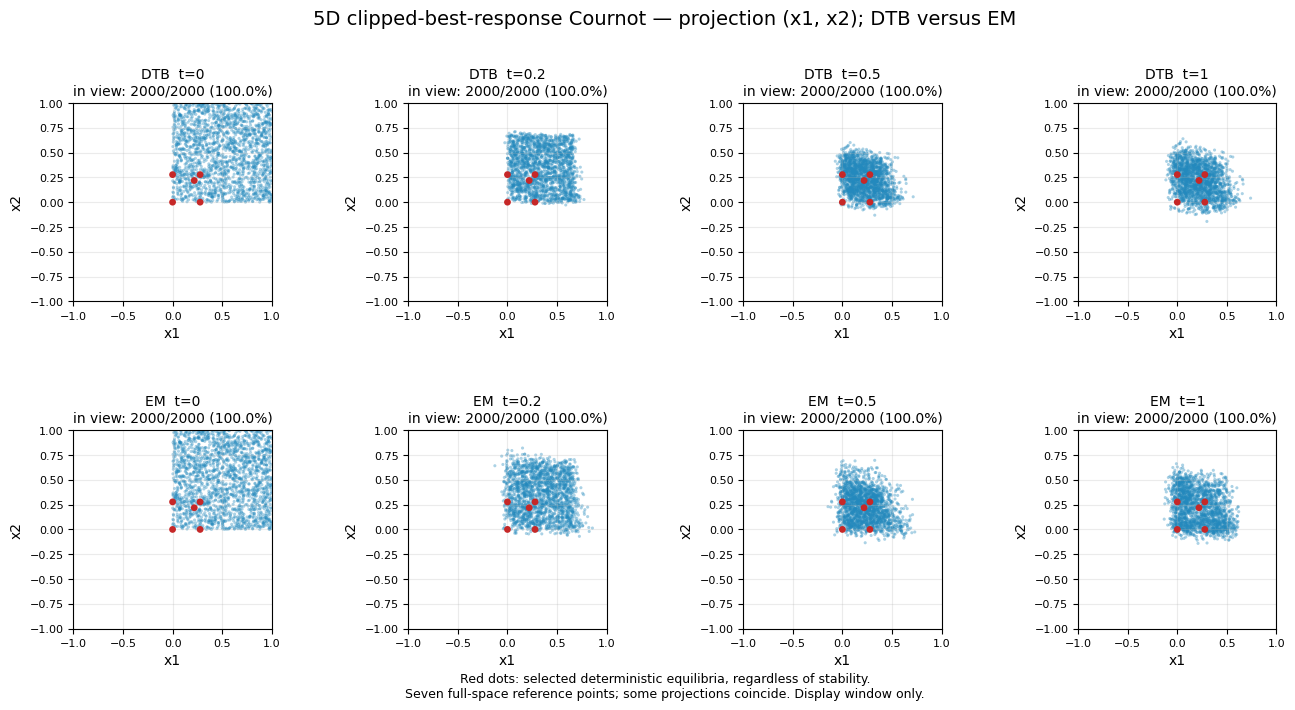

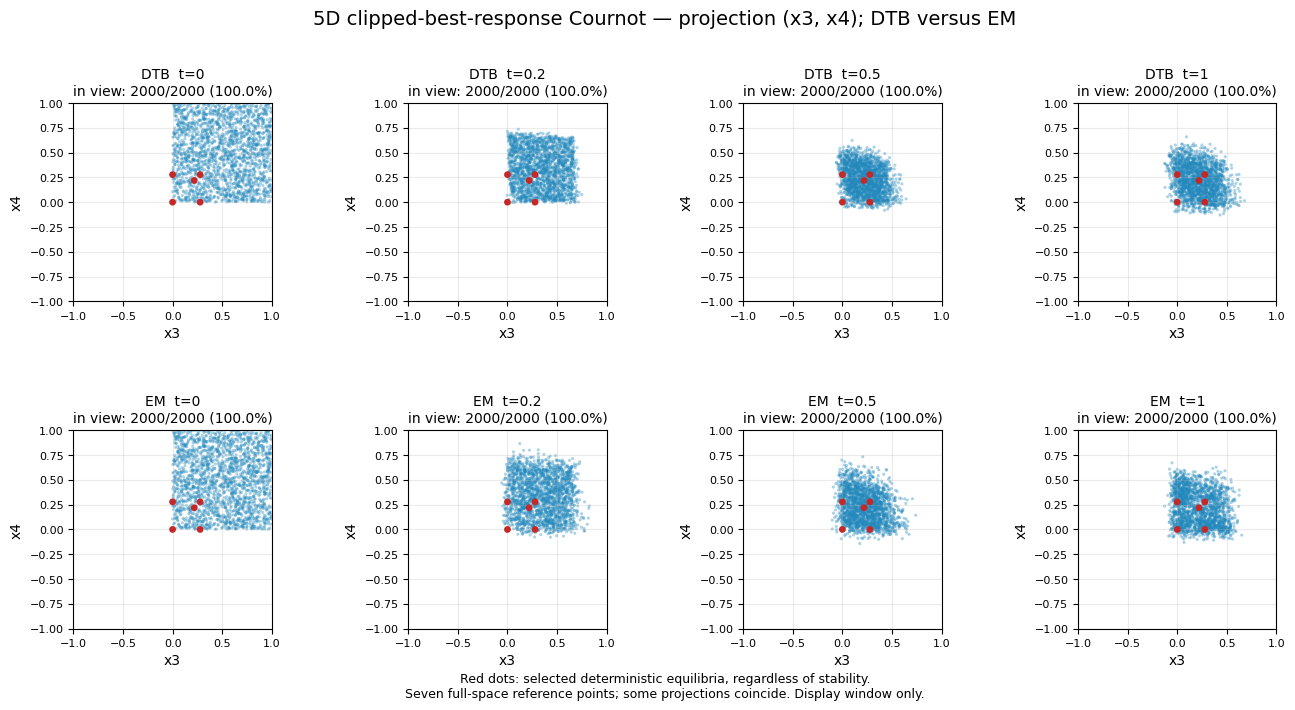

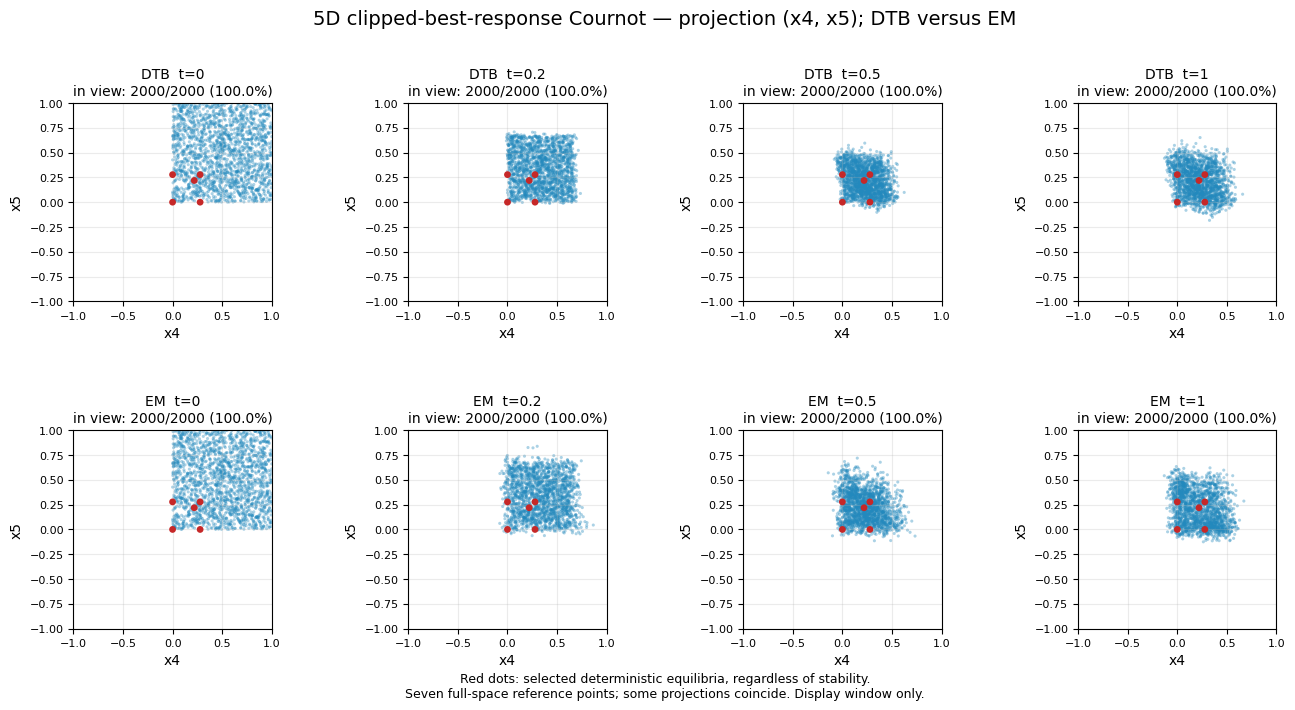

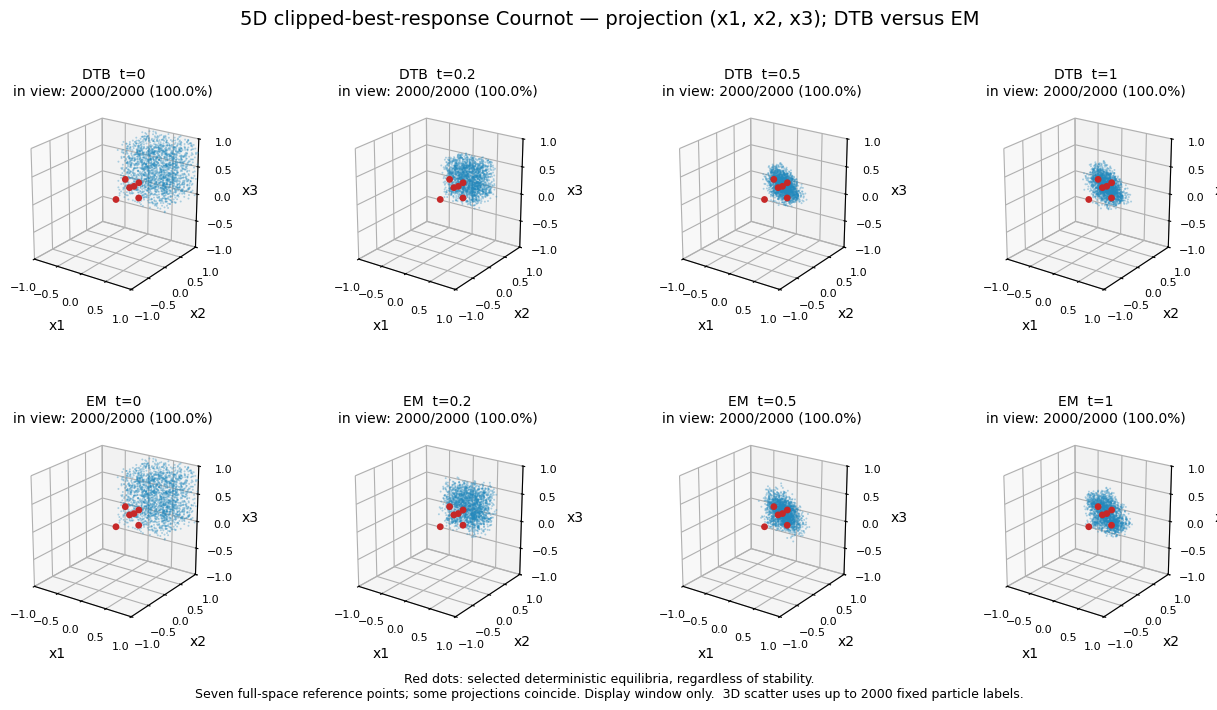

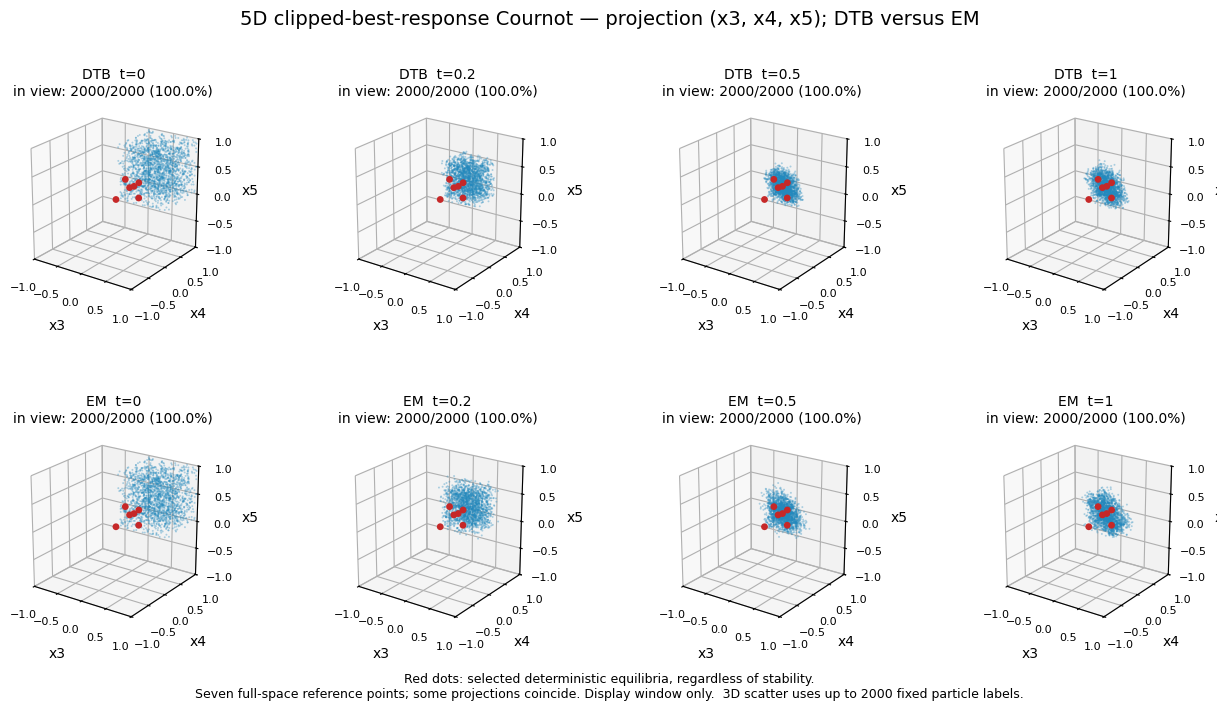

In [17]:
if len(PLOT_LIMITS) != 2 or not np.isfinite(PLOT_LIMITS).all() or PLOT_LIMITS[0] >= PLOT_LIMITS[1]:
    raise ValueError('PLOT_LIMITS must contain increasing finite bounds.')
if PLOT_3D_MAX_POINTS is not None and (not isinstance(PLOT_3D_MAX_POINTS, int) or PLOT_3D_MAX_POINTS < 1):
    raise ValueError('PLOT_3D_MAX_POINTS must be None or a positive integer.')
for result in runs.values():
    if result is not None:
        assert result['particles'].shape == (len(result['times']), N_PARTICLES, DIM)
        assert np.isfinite(result['particles']).all()
references = KNOWN_EQUILIBRIA.detach().cpu().numpy()
display_indices = np.arange(N_PARTICLES)
if PLOT_3D_MAX_POINTS is not None and PLOT_3D_MAX_POINTS < N_PARTICLES:
    display_indices = np.sort(np.random.default_rng(SEED).choice(
        N_PARTICLES, size=PLOT_3D_MAX_POINTS, replace=False))

def plot_coordinate_snapshots(coordinates):
    count = len(coordinates)
    if count not in (2, 3) or len(set(coordinates)) != count or any(i not in range(1, DIM+1) for i in coordinates):
        raise ValueError('A projection needs two or three distinct one-based coordinate indices.')
    dimensions = [i - 1 for i in coordinates]
    # Distinct full-space equilibria may coincide in a coordinate projection.
    unique_references = np.unique(references[:, dimensions], axis=0)
    options = {'projection': '3d', 'computed_zorder': False} if count == 3 else {}
    fig, axes = plt.subplots(2, len(SNAPSHOT_TIMES), squeeze=False,
                             figsize=(3.3 * len(SNAPSHOT_TIMES), 7.2), subplot_kw=options)
    for row, (name, result) in enumerate(runs.items()):
        for column, t in enumerate(SNAPSHOT_TIMES):
            ax = axes[row, column]
            index = snapshot_index(result, t)
            title = f'{name.upper()}  t={t:g}'
            if index is None:
                ax.set_title(title)
                ax.set_axis_off()
                text_fn = ax.text2D if count == 3 else ax.text
                text_fn(0.5, 0.5, unavailable_reason(result, t), transform=ax.transAxes,
                        ha='center', va='center', fontsize=9, color='#666666')
                continue
            points = result['particles'][index][:, dimensions]
            visible = ((points >= PLOT_LIMITS[0]) & (points <= PLOT_LIMITS[1])).all(axis=1)
            # Omit off-window points from the scatter only (especially important for 3D autoscaling).
            selected = display_indices if count == 3 else np.arange(N_PARTICLES)
            shown = points[selected][visible[selected]]
            ax.scatter(*shown.T, s=PLOT_3D_POINT_SIZE if count == 3 else 5,
                       alpha=PLOT_3D_ALPHA if count == 3 else 0.38, color='#2389bd',
                       edgecolors='none', rasterized=True)
            ax.scatter(*unique_references.T, s=24, c='#c62828', marker='o',
                       edgecolors='none', zorder=5,
                       **({'depthshade': False} if count == 3 else {}))
            ax.set_title(title + f'\nin view: {visible.sum()}/{N_PARTICLES} ({visible.mean():.1%})', fontsize=10)
            ax.set(xlim=PLOT_LIMITS, ylim=PLOT_LIMITS,
                   xlabel=f'x{coordinates[0]}', ylabel=f'x{coordinates[1]}')
            ax.tick_params(labelsize=8)
            if count == 3:
                ax.set(zlim=PLOT_LIMITS, zlabel=f'x{coordinates[2]}')
                ax.view_init(elev=PLOT_3D_ELEV, azim=PLOT_3D_AZIM)
                ax.set_box_aspect((1, 1, 1))
            else:
                ax.set_aspect('equal', adjustable='box')
                ax.grid(alpha=0.25)
    projection = ', '.join(f'x{i}' for i in coordinates)
    fig.suptitle(f'5D clipped-best-response Cournot — projection ({projection}); DTB versus EM', fontsize=14, y=0.98)
    subset_note = f'  3D scatter uses up to {len(display_indices)} fixed particle labels.' if count == 3 else ''
    fig.text(0.5, 0.025,
             'Red dots: selected deterministic equilibria, regardless of stability.\n'
             'Seven full-space reference points; some projections coincide. Display window only.'
             + subset_note, ha='center', fontsize=9)
    fig.subplots_adjust(left=0.035, right=0.95 if count == 3 else 0.98,
                        bottom=0.12, top=0.85, hspace=0.65, wspace=0.38)
    return fig

snapshot_figures = {}
for coordinates in (*COORDINATE_PAIRS, *COORDINATE_TRIPLES):
    figure = plot_coordinate_snapshots(coordinates)
    name = 'dtb_vs_em_' + '_'.join(f'x{i}' for i in coordinates)
    snapshot_figures[name] = figure
    if output_dir is not None:
        figure.savefig(output_dir / f'{name}.png', dpi=160, bbox_inches='tight')
plt.show()

## Block 7 — Diagnostics, per-step timing, and export

The same DTB projection-error and coefficient-norm diagnostics are retained.
Additional plots show full-ensemble state magnitudes, per-attempt durations,
and score growth. Very large but finite coordinates remain visible in the
log-scale health plot even when they lie outside the snapshot window.

Set `SAVE_RUN=True` in Block 1 before running Blocks 5–7 to save figures,
separate time grids and valid histories, DTB scores/coefficient histories,
every attempt's duration, stopping reasons, and configuration. The folder
name includes `clippedBR`, architecture, parameter tuple `(b, mu, sigma1, ..., sigma5)`,
sample size N, tangent-basis size and seed. Outputs are local to the runtime;
this cell does not upload credentials or push generated data to GitHub.

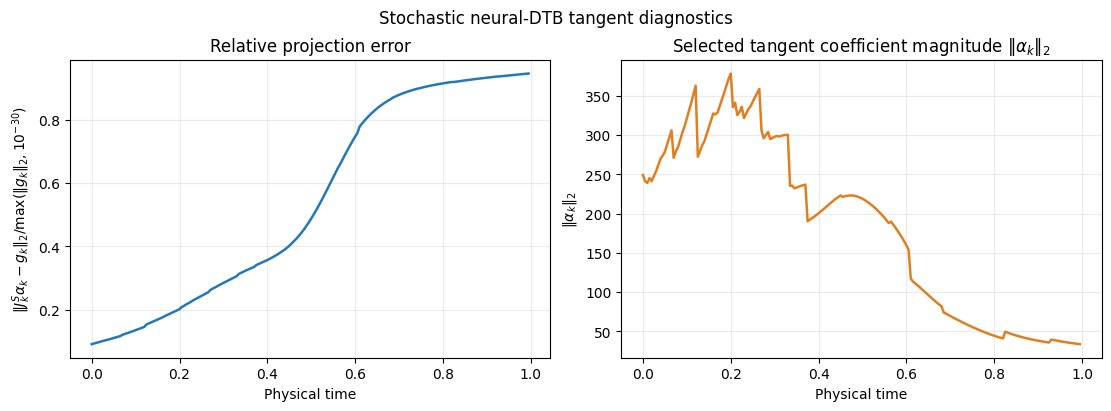

## Stochastic DTB diagnostics

| Metric | Mathematical definition | First | Mean | Final |
| :--- | :--- | ---: | ---: | ---: |
| Relative projection error | $r_k=\frac{\|J_k^S\alpha_k-g_k\|_2}{\max(\|g_k\|_2,10^{-30})}$ | 9.0289e-02 | 5.4498e-01 | 9.4759e-01 |
| Coefficient magnitude | $a_k=\|\alpha_k\|_2$ | 2.4916e+02 | 1.8231e+02 | 3.3685e+01 |
| Score RMS | $s_k=\sqrt{N^{-1}\sum_i\|q_i^k\|_2^2}$ | 0.0000e+00 | 1.7446e+00 | 3.9583e+00 |
| Diffusion correction RMS | $c_k=\frac{1}{2\sqrt N}\|Dq_k\|_2$ | 0.0000e+00 | 8.7232e-03 | 1.9791e-02 |
| Target velocity RMS | $v_k^g=N^{-1/2}\|g_k\|_2$ | 2.5529e+00 | 8.4278e-01 | 1.8192e-01 |
| Tangent velocity RMS | $v_k^u=N^{-1/2}\|u_k\|_2$ | 2.5425e+00 | 7.7453e-01 | 5.8121e-02 |

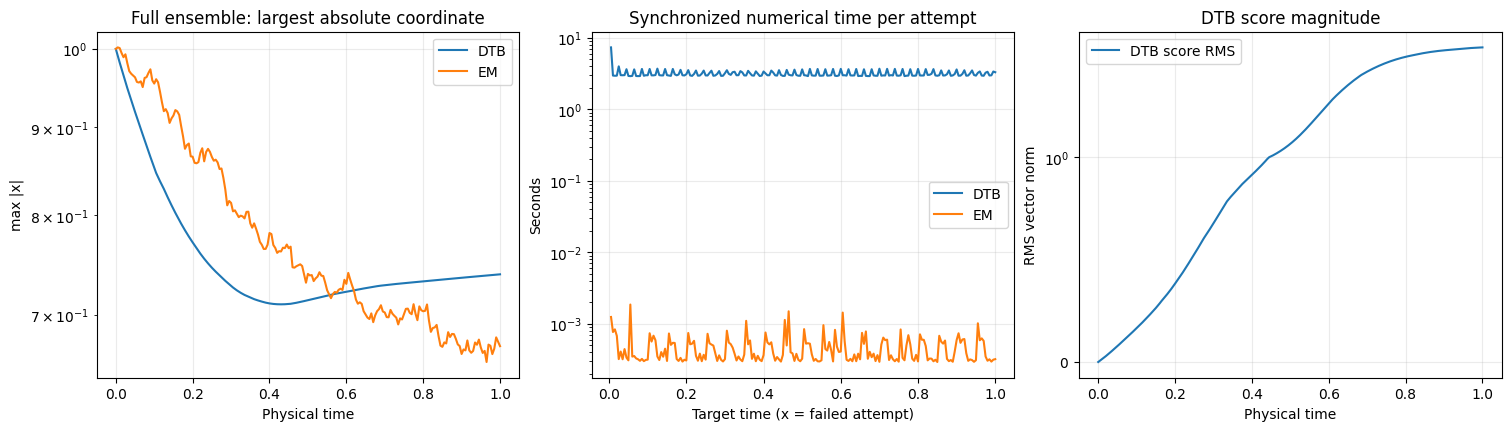

SAVE_RUN=False: results are available in dtb_result / em_result; no output folder created.


In [18]:
records = [] if dtb_result is None else dtb_result['diagnostics']
relative_projection_errors = np.asarray([record['relative_projection_error'] for record in records])
alpha_norms = np.asarray([record['alpha_norm'] for record in records])
diagnostics_figure = None
if records:
    diagnostics_figure = plot_tangent_diagnostics(
        dtb_result['solve_times'], relative_projection_errors, alpha_norms,
        output_path=None if output_dir is None else output_dir / 'tangent_diagnostics.png',
    )
    metric_table = diagnostics_markdown(records)
else:
    metric_table = 'No accepted DTB steps: tangent diagnostics are unavailable.'
plt.show()
display(Markdown('## Stochastic DTB diagnostics'))
display(Markdown(metric_table))


health_figure, health_axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
for name, result in runs.items():
    if result is None:
        continue
    max_abs = np.abs(result['particles'].astype(np.float64)).max(axis=(1, 2))
    attempt_times = np.arange(1, result['attempted_steps'] + 1) * result['step_size']
    health_axes[0].semilogy(result['times'], np.maximum(max_abs, 1e-30), label=name.upper())
    health_axes[1].semilogy(attempt_times, np.maximum(result['step_seconds'], 1e-12), label=name.upper())
    if result['status'] == 'stopped':
        health_axes[1].scatter([result['failed_time']], [max(result['step_seconds'][-1], 1e-12)], marker='x', s=60)
health_axes[0].set(title='Full ensemble: largest absolute coordinate', xlabel='Physical time', ylabel='max |x|')
health_axes[1].set(title='Synchronized numerical time per attempt', xlabel='Target time (x = failed attempt)', ylabel='Seconds')
if dtb_result is not None:
    score_rms = np.linalg.norm(dtb_result['scores'].astype(np.float64), axis=(1, 2)) / math.sqrt(N_PARTICLES)
    health_axes[2].plot(dtb_result['times'], score_rms, label='DTB score RMS')
    health_axes[2].set_yscale('symlog', linthresh=1)
health_axes[2].set(title='DTB score magnitude', xlabel='Physical time', ylabel='RMS vector norm')
for ax in health_axes:
    ax.grid(alpha=0.25)
    if ax.get_legend_handles_labels()[0]:
        ax.legend()
if output_dir is not None:
    health_figure.savefig(output_dir / 'state_health_and_step_timing.png', dpi=180, bbox_inches='tight')
plt.show()

if output_dir is not None:
    # A run's own time grid is saved alongside its (possibly shorter) valid history.
    arrays = {}
    summary_keys = (
        'method', 'step_size', 'requested_final_time', 'requested_steps', 'max_abs_state',
        'status', 'stop_reason', 'failed_step', 'failed_time', 'completed_steps',
        'attempted_steps', 'last_valid_time', 'compute_seconds', 'mean_attempt_seconds',
        'wall_seconds', 'metadata',
    )
    run_summaries = {}
    for name, result in runs.items():
        if result is None:
            run_summaries[name] = {'status': 'not run'}
            continue
        run_summaries[name] = {key: result[key] for key in summary_keys}
        arrays[f'{name}_times'] = result['times']
        arrays[f'{name}_particles'] = result['particles']
        arrays[f'{name}_step_seconds'] = result['step_seconds']
    if dtb_result is not None:
        arrays.update(
            solve_times=dtb_result['solve_times'], scores=dtb_result['scores'],
            log_density=dtb_result['log_density'], coefficients=dtb_result['coefficients'],
            selected_parameter_indices=np.asarray(dtb_result['metadata']['selected_parameter_indices']),
            relative_projection_error=relative_projection_errors, alpha_norm=alpha_norms,
            **{f'diagnostic_{key}': np.asarray([row[key] for row in records])
               for key in ('score_rms', 'diffusion_rms', 'target_rms', 'tangent_rms',
                           'score_transport_rms', 'score_source_rms')},
        )
    saved_config = {
        **CONFIG, 'runs': run_summaries, 'common_horizon_timing': common_timing,
        'snapshot_times': list(SNAPSHOT_TIMES), 'save_run': True, 'output_dir': str(output_dir),
        'coordinate_pairs': [list(pair) for pair in COORDINATE_PAIRS],
        'plot_limits': list(PLOT_LIMITS),
        'coordinate_triples': [list(triple) for triple in COORDINATE_TRIPLES],
        'plot_3d_max_points': PLOT_3D_MAX_POINTS,
        'plot_3d_elevation': PLOT_3D_ELEV, 'plot_3d_azimuth': PLOT_3D_AZIM,
        'plot_3d_point_size': PLOT_3D_POINT_SIZE, 'plot_3d_alpha': PLOT_3D_ALPHA,
    }
    stop_notes = '\n'.join(
        f'{result["method"]}: {result["stop_reason"]} (attempt {result["failed_step"]}, '
        f't={result["failed_time"]:.6g}; last valid t={result["last_valid_time"]:.6g}).'
        for result in runs.values() if result is not None and result['status'] == 'stopped'
    )
    save_run_data(
        output_dir, config=saved_config, arrays=arrays,
        metrics_markdown='\n\n'.join([
            timing_table, CONFIG['timing_scope'], common_timing_text, stop_notes,
            availability_table, reference_table, metric_table,
        ]),
    )
    print('Saved valid histories, per-method times/status, figures, and timings to:', output_dir)
else:
    print('SAVE_RUN=False: results are available in dtb_result / em_result; no output folder created.')

## Interpretation and numerical checks

The drift now uses a nonnegative best response, not the previous raw quadratic
field. In particular, $0\le B_i^+\le\mu/4$, while the remaining term is
$-2b x_i$. Earlier overflow observations for the **unclipped** notebook do
not describe this revised experiment.

This modification does not guarantee the accuracy or stability of the neural
tangent approximation or score evolution. Inspect projection error,
coefficient norm, score growth and full-state range. If a run stops, the
status table identifies the rejected attempt and later snapshots are unavailable.

The seven displayed references satisfy the revised deterministic fixed-point
equations. They are shown **even when unstable**, and are not an exhaustive
equilibrium list. Noisy particles need not converge to these exact points.

To check time-discretization sensitivity, keep the initial law, noise amplitude
and horizon unchanged while decreasing a method's step size. Equal seeds at
different EM step sizes do not create coupled Brownian paths; pathwise tests
require consistently aggregated increments. Reflecting or clipping particle
positions would be another model change and is **not** performed here.

**Local validation:** with the default N=2000, h=0.005, seed=2026 and
CPU float32 / PyTorch 2.12.1, both DTB and EM completed all 200 steps
through T=1 with finite saved states. The seven reference residuals,
smooth-region Jacobians, independent reruns, equilibrium markers, timings,
exports and first-step-failure handling were checked. Completing the
horizon is a numerical health check, not a guarantee of DTB accuracy.